# <center>M2 MIND -   ADL</center>
##  <center>  Generative Adversarial Networks  </center>

Ce TME a pour objectif d'expérimenter les Generative Adversarial Networks
(GANs) sur un problème de génération de visages.

De manière classique, un GAN se formule selon un problème adverse de la
manière suivante: $$\min\limits_{G} \max\limits_D V(D,G) = \mathbb{E}_{x\sim
p_{data}(x)}\big[logD(x)\big] + \mathbb{E}_{z\sim
p_{z}(z)}\big[log(1-D(G(z)))\big]$$ Cette formulation met en jeu deux réseaux
adverse:
*   Un réseau discriminateur $D$, dont l'objectif est de savoir distinguer les
    données réelles des données simulées
*   Un réseau générateur $G$, dont l'objectif est de flouer le discriminateur

À l'optimum, avec des réseaux de capacité infinie, la distribution $p_G$ des
données générées par $G$ est prouvée suivre la distribution des données
réelles $p_{data}$. Bien sûr nous ne travaillons pas avec des réseaux de
capacité infinie (et d'ailleurs heureusement car on ne veut pas apprendre par
coeur les données d'apprentissage), mais l'objectif est d'approcher cette
distribution $p_{data}$ en apprenant un générateur neuronal dont les sorties
sont difficilement distinguables des vraies données pour le discriminateur.

Nous proposons de mettre ce genre d'architecture pour un la génération de
visages: selon un ensemble de visages d'entraînement, il s'agit d'apprendre à
générer des visages qui paraissent les plus réalistes possibles tout en
conservant une certaine diversité dans les distributions de sortie. Pour cela
nous emploierons une architecture DCGAN, qui utilise des réseaux de neurones
convolutionnels (CNNs) pour le générateur et le discriminateur.

In [1]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.utils.data
import torchvision.datasets as dset
import torchvision.utils as vutils
import torch.backends.cudnn as cudnn

import os

In [2]:
cache_dir = os.environ.get(
    "TORCHVISION_CACHE", os.path.expanduser("~/.cache/torchvision")
)
cache_dir

'C:\\Users\\titou/.cache/torchvision'

Le code ci-dessous permet de déclarer la manière de charger les données.

Lorsque des données sont demandées (pour la construction d'un nouveau batch
par exemple), une série de transformations est appliquée sur les images, selon
la composition de transformateurs déclarée pour le chargement:
*    redimentionnement des images en 64 par 64
*    recadrage au centre (qui ne fait rien ici car image déjà dans la taille
     du cadre mais si utile pour d'autres paramètres)
*    conversion en tenseur pytorch
*    normalisation des valeurs RGB selon une moyenne de 0.5 et un ecart-type
     de 0.5.

In [4]:
image_size = 64
dataset = dset.CelebA(
    root=cache_dir,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    ),
    download=True,
)

print(dataset)

Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=53b2e94d-27ff-40e1-91b6-b0764579787f
To: C:\Users\titou\.cache\torchvision\celeba\img_align_celeba.zip
100%|██████████| 1.44G/1.44G [01:11<00:00, 20.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: C:\Users\titou\.cache\torchvision\celeba\list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:01<00:00, 18.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: C:\Users\titou\.cache\torchvision\celeba\identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 13.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: C:\Users\titou\.cache\torchvision\celeba\list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 16.8MB/s]
Downloading...
From: https://drive.g

Dataset CelebA
    Number of datapoints: 162770
    Root location: C:\Users\titou/.cache/torchvision
    Target type: ['attr']
    Split: train
    StandardTransform
Transform: Compose(
               Resize(size=64, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(64, 64))
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )


Le code ci-dessous permet de déclarer la manière de charger les images et en
affiche un échantillon.

Running on CUDA


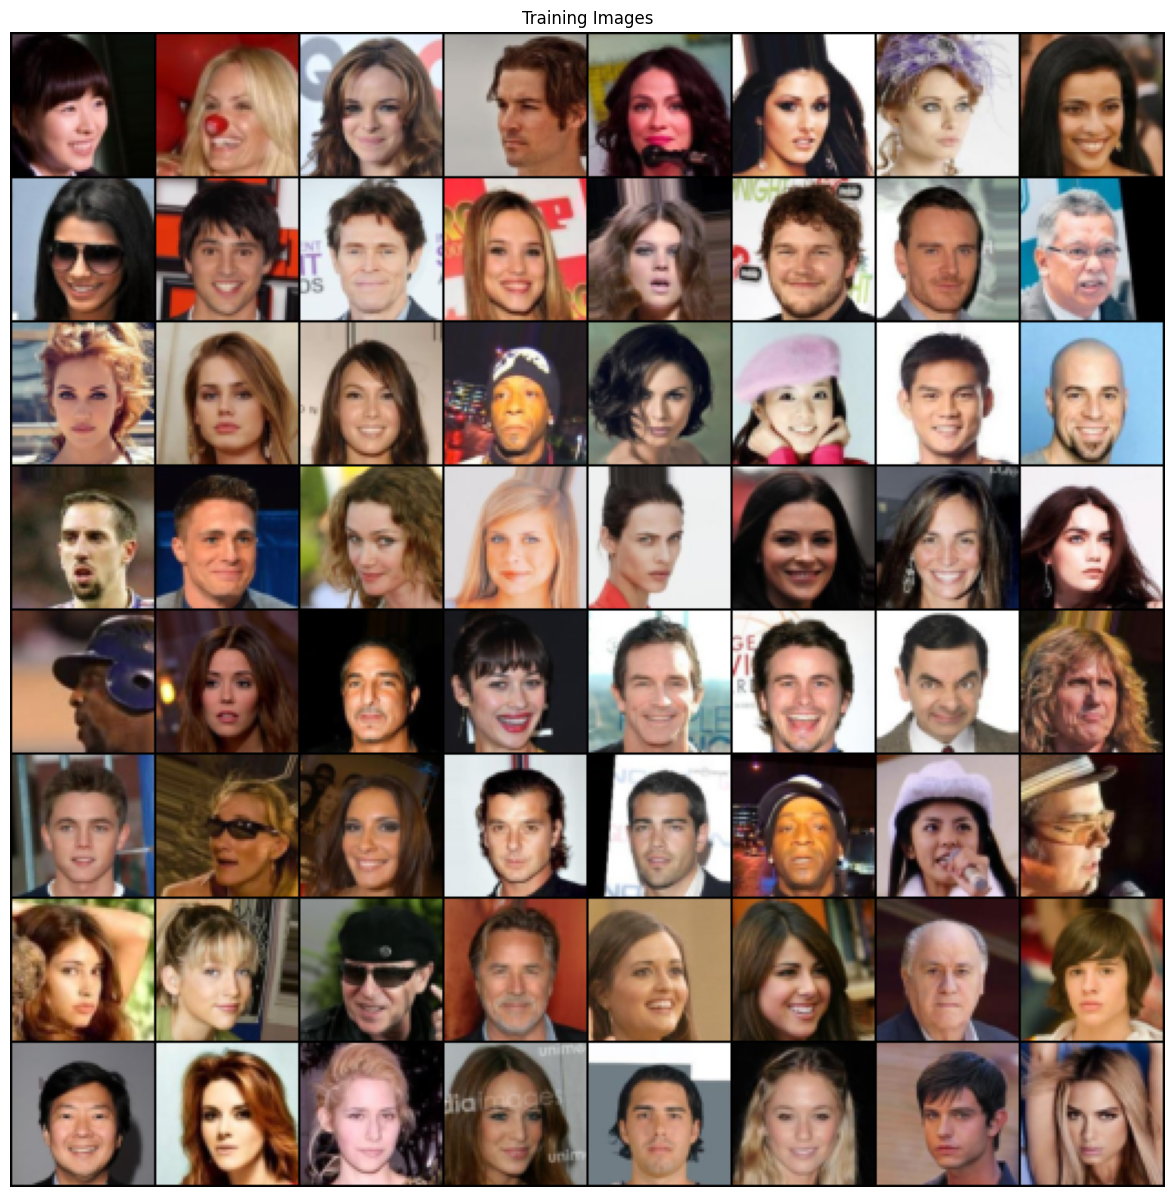

In [5]:
import matplotlib.pyplot as plt
import os


seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    print("Running on CUDA")
    cudnn.benchmark = True
    device = torch.device("cuda:0")
    torch.cuda.manual_seed(seed)
elif torch.backends.mps.is_available():
    print("Running on MPS")
    device = torch.device("mps")
else:
    print("WARNING: running on CPU")
    device = torch.device("cpu")

batch_size = 128
workers = 2

dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True, num_workers=workers
)

# Affichage de quelques images
real_batch = next(
    iter(dataloader)
)  # real_batch est une liste de 2 tenseurs où le 1er correspond aux images, les second correspond aux labels (ici 0 partout)

plt.figure(figsize=(15, 15))
plt.axis("off")
plt.title("Training Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(
            real_batch[0].to(device)[:64], padding=1, normalize=True
        ).cpu(),
        (1, 2, 0),
    )
)

Le réseau $D$ est un empilement de couches de convolution 2D avec batchNorm2D
et activations RELU:

In [6]:
# Nombre de canaux de l'entrée
nc = 3

# Facteur du nombre de canaux de sortie des différentes couches de convolution
ndf = 64  


# Initialisation recommandee pour netG et netD dans DCGAN
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Discriminator(nn.Module):
    """Outputs a logit"""
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, input):
        return self.main(input)


netD = Discriminator().to(device)
netD.apply(weights_init)
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)


In [7]:
nz = 100  # Taille du vecteur z donné en entrée du générateur
ngf = (
    64  # Facteur du nombre de canaux de sortie des différentes couches de déconvolution
)


class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)


netG = Generator().to(device)
netG.apply(weights_init)
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


Donner la procédure d'entraînement de ces deux réseaux. L'optimisation se fera
ADAM selon les deux coûts adverses du discriminateur et du générateur. Pour
chaque nouveau batch d'images, on alterne les deux mises à jour suivantes,
selon un batch de vecteurs $z$ tirés aléatoirement selon une loi normale
centrée réduite (un nouveau batch de $z$ à chaque itération):

1.   Un pas de gradient sur les paramètres du réseau D pour maximiser:
     $log(D(x)) + log(1 - D(G(z)))$
2.   Un pas de gradient sur les paramètres du réseau G pour maximiser : $log(D(G(z)))$. 
   - **Question :** pourquoi ne pas minimiser $log(1-D(G(z)))$ comme la formulation initiale le suggère ?


Afin de suivre l'évolution de l'apprentissage, on pourra logguer l'erreur du
discriminateur relevée en 1, l'erreur du générateur relevée en 2, la moyenne
des sorties du discriminateur sur les images réelles et la moyenne des sorties
du discriminateur sur les images générées.

À la fin de chaque époque (i.e., lorsque l'on a itéré sur tous les batchs du
DataLoader), on pourra enregistrer les images générées à partir d'un batch de
vecteurs $z$ fixe dans le Google Drive pour observer l'évolution des capacités
du générateur.

In [9]:
# Implémenter la boucle d'apprentissage
criterion = nn.BCEWithLogitsLoss()

lr = 2e-4
beta1 = 0.5

# need 2 optimizers one for discriminator and one for generator
optimizerD = torch.optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# the noise is fixed here for training because we want to see how 
# the same noise will impact images (easier to track progress!)
fixed_z = torch.randn(64, nz, 1, 1, device=device) # nz bc of input size of generator

num_epochs = 5 # 5 should be enough bc one epoch already takes a good amount of time (even on cuda)

for epoch in range(num_epochs):

    for i, data in enumerate(dataloader): # over batches
        netD.zero_grad()

        real_images = data[0].to(device)
        batch_size = real_images.size(0)

        # fetch the real and faake labels (either ones or zeros)
        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # real images 
        output_real = netD(real_images).view(-1)
        loss_real = criterion(output_real, real_labels)

        # generate the fake images with the generator
        z = torch.randn(batch_size, nz, 1, 1, device=device)
        fake_images = netG(z)
        output_fake = netD(fake_images.detach()).view(-1) # remove from computational graph 
        loss_fake = criterion(output_fake, fake_labels) # get loss

        # discriminator takes loss from both real and fake images
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        #update the gen
        netG.zero_grad()
        output = netD(fake_images).view(-1)
        loss_G = criterion(output, real_labels)

        loss_G.backward()
        optimizerG.step()

        if i % 50 == 0:
            D_x = torch.sigmoid(output_real).mean().item()
            D_G_z = torch.sigmoid(output).mean().item()

            # stats to print
            p_epoch = f"[Epoch {epoch}/{num_epochs}] "
            p_batch = f"[Batch {i}/{len(dataloader)}] "
            p_loss_d = f"Loss_D: {loss_D.item():.4f} "
            p_loss_g = f"Loss_G: {loss_G.item():.4f} "
            p_dx = f"D(x): {D_x:.4f} "
            p_dgz = f"D(G(z)): {D_G_z:.4f}"
            print(p_epoch, p_batch, p_loss_d, p_loss_g, p_dx, p_dgz)

    # generate some fake images after each epoch to track progress
    with torch.no_grad():
        fake = netG(fixed_z).cpu()
    # grid format and save
    grid = vutils.make_grid(fake, normalize=True, padding=2)
    plt.imsave(
        f"epoch_{epoch}.png",
        np.transpose(grid, (1, 2, 0)),
    )


[Epoch 0/5] [Batch 0/1272] Loss_D: 0.6964 Loss_G: 0.1899 D(x): 0.6643 D(G(z)): 0.8357
[Epoch 0/5] [Batch 50/1272] Loss_D: 0.8093 Loss_G: 3.9785 D(x): 0.8714 D(G(z)): 0.0297
[Epoch 0/5] [Batch 100/1272] Loss_D: 0.6089 Loss_G: 2.1078 D(x): 0.6289 D(G(z)): 0.1611
[Epoch 0/5] [Batch 150/1272] Loss_D: 0.6030 Loss_G: 4.3820 D(x): 0.8793 D(G(z)): 0.0170
[Epoch 0/5] [Batch 200/1272] Loss_D: 0.3768 Loss_G: 2.8126 D(x): 0.8043 D(G(z)): 0.0844
[Epoch 0/5] [Batch 250/1272] Loss_D: 0.5778 Loss_G: 3.3014 D(x): 0.8840 D(G(z)): 0.0476
[Epoch 0/5] [Batch 300/1272] Loss_D: 1.1595 Loss_G: 0.6607 D(x): 0.4162 D(G(z)): 0.5651
[Epoch 0/5] [Batch 350/1272] Loss_D: 0.4975 Loss_G: 2.1395 D(x): 0.7958 D(G(z)): 0.1437
[Epoch 0/5] [Batch 400/1272] Loss_D: 0.4872 Loss_G: 2.2605 D(x): 0.7604 D(G(z)): 0.1373
[Epoch 0/5] [Batch 450/1272] Loss_D: 0.8076 Loss_G: 4.7400 D(x): 0.9598 D(G(z)): 0.0119
[Epoch 0/5] [Batch 500/1272] Loss_D: 0.8719 Loss_G: 4.5147 D(x): 0.9025 D(G(z)): 0.0157
[Epoch 0/5] [Batch 550/1272] Loss_D

Le code ci-dessous applique votre réseau à un
batch de $z$ aléatoires et affiche les images générées (et enregistre dans
fake.png).

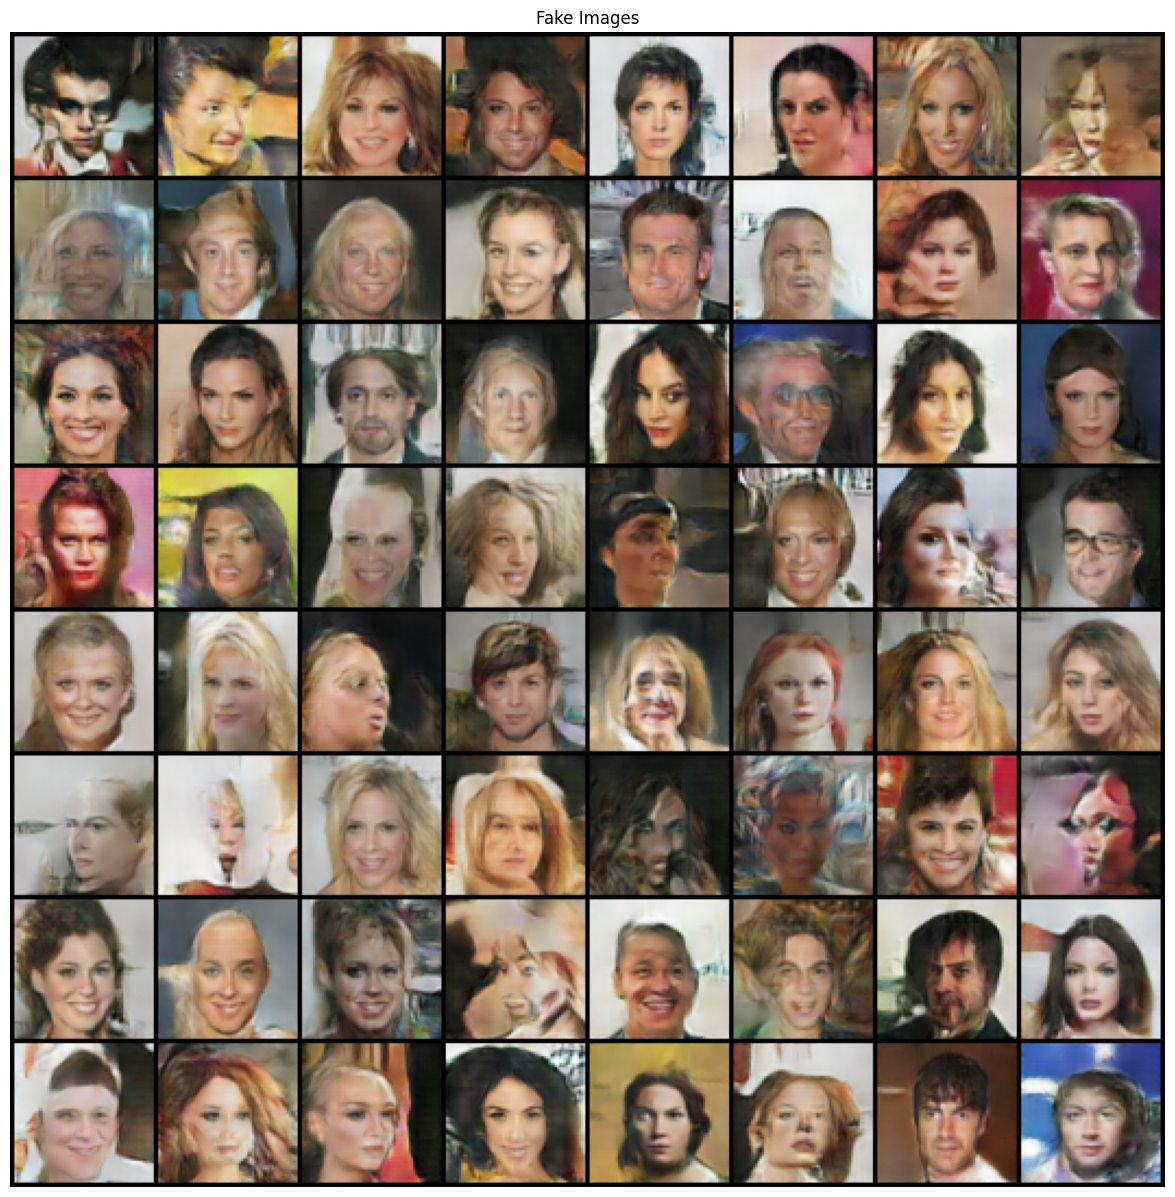

In [ ]:
img_list = [] # added this cuz it was missing
noise = torch.randn(64, nz, 1, 1, device=device) # use differnet noise than during training (our fixed z)
with torch.no_grad():
    netG.eval()
    fake = netG(noise).detach().cpu()
img = vutils.make_grid(fake, padding=2, normalize=True)
img_list.append(img)
plt.figure(figsize=(15, 15))
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img.cpu(), (1, 2, 0)))
plt.savefig("fake.png")

# Bonus: Générateur

Le générateur du papier original DCGAN possède en fait l'architecture
suivante:

![Generator](https://pytorch.org/tutorials/_images/dcgan_generator.png)

Comme le réseau $G$ définit plus haut, il correspond à un empilement de
couches de convolutions transposées (appelée dans certains papiers couches de
déconvolution). Contrairement aux convolutions classiques qui mènent à une
réduction de la taille des sorties, les convolutions transposées agrandissent
les cartes de caractéristiques considérées (feature maps). C'est
particulièrement adapté pour de la génération d'images à partir d'un code de
petite taille (ici $z$).

 Pour comprendre comment fonctionne la convolution transposée, voici un
 exemple simple avec une entrée 2 x 2 et un noyau 2 x 2. Chaque élément de
 l'entrée (4 éléments) est multiplié par le noyau et le résultat est ajouté à
 la sorte de taille 3 x 3:

![BasicTransposeConv2D](https://d2l.ai/_images/trans_conv.svg)

Et voici deux animations pour se représenter l'opération d'une manière plus
générale. A gauche on utilise un stride de 1, à droite un stride de 2:

<p align="center">
<img src="https://i.stack.imgur.com/YyCu2.gif">
<img src="https://i.stack.imgur.com/f2RiP.gif">
</p>


Suivant la doc Pytorch de torch.nn.ConvTranspose2d, la hauteur $H_{out}$ et la
largeur $W_{out}$ des cartes de sortie du ConvTranspose2d peuvent se calculer
de la manière suivante:

$H_{out}$=($H_{in}$−1)×stride−2×padding+dilation×(kernel_size−1)+output_padding+1

$W_{out}$=($W_{in}$−1)×stride−2×padding+dilation×(kernel_size−1)+output_padding+1


Proposer un nouveau réseau $G$ qui respecte l'architecture du schéma du papier
DCGAN et comparer les résultats. On gardera le paramètre de dilation à sa
valeur de 1 par défaut mais il est possible de moduler les valeurs de padding
et output_padding pour obtenir des sorties de la taille désirée.

In [11]:
#  Implémenter le nouveau générateur (puis l'entraîner)
class DCGANGenerator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()

        self.main = nn.Sequential(
            # z is a zn (100) by 1 by 1 so (ngf*16) by 4 by 4
            nn.ConvTranspose2d(nz, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),

            # 4x4 to 8x8
            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            # 8x8 to 16x16
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            # 16x16 to 32x32
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # 32x32 to 64x64
            nn.ConvTranspose2d(ngf * 2, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

In [12]:
# CHANGE THE GAN NETWORK TO THE DCGAN GENERATOR
netG = DCGANGenerator(nz=nz, ngf=ngf, nc=nc).to(device)
netG.apply(weights_init)
print(netG)

DCGANGenerator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Ta

In [13]:
# shouldve made a function for training the GAN earlier but oh well
# retook the code but just changed the gan netork to our new one

criterion = nn.BCEWithLogitsLoss()

lr = 2e-4
beta1 = 0.5

# need 2 optimizers one for discriminator and one for generator
optimizerD = torch.optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# the noise is fixed here for training because we want to see how 
# the same noise will impact images (easier to track progress!)
fixed_z = torch.randn(64, nz, 1, 1, device=device) # nz bc of input size of generator

num_epochs = 5 # 5 should be enough bc one epoch already takes a good amount of time (even on cuda)

for epoch in range(num_epochs):

    for i, data in enumerate(dataloader): # over batches
        netD.zero_grad()

        real_images = data[0].to(device)
        batch_size = real_images.size(0)

        # fetch the real and faake labels (either ones or zeros)
        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # real images 
        output_real = netD(real_images).view(-1)
        loss_real = criterion(output_real, real_labels)

        # generate the fake images with the generator
        z = torch.randn(batch_size, nz, 1, 1, device=device)
        fake_images = netG(z)
        output_fake = netD(fake_images.detach()).view(-1) # remove from computational graph 
        loss_fake = criterion(output_fake, fake_labels) # get loss

        # discriminator takes loss from both real and fake images
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        #update the gen
        netG.zero_grad()
        output = netD(fake_images).view(-1)
        loss_G = criterion(output, real_labels)

        loss_G.backward()
        optimizerG.step()

        if i % 50 == 0:
            D_x = torch.sigmoid(output_real).mean().item()
            D_G_z = torch.sigmoid(output).mean().item()

            # stats to print
            p_epoch = f"[Epoch {epoch}/{num_epochs}] "
            p_batch = f"[Batch {i}/{len(dataloader)}] "
            p_loss_d = f"Loss_D: {loss_D.item():.4f} "
            p_loss_g = f"Loss_G: {loss_G.item():.4f} "
            p_dx = f"D(x): {D_x:.4f} "
            p_dgz = f"D(G(z)): {D_G_z:.4f}"
            print(p_epoch, p_batch, p_loss_d, p_loss_g, p_dx, p_dgz)

    # generate some fake images after each epoch to track progress
    with torch.no_grad():
        fake = netG(fixed_z).cpu()
    # grid format and save
    grid = vutils.make_grid(fake, normalize=True, padding=2)
    plt.imsave(
        f"epoch_{epoch}.png",
        np.transpose(grid, (1, 2, 0)),
    )


[Epoch 0/5]  [Batch 0/1272]  Loss_D: 0.1642  Loss_G: 6.5973  D(x): 0.8598  D(G(z)): 0.0028
[Epoch 0/5]  [Batch 50/1272]  Loss_D: 0.0037  Loss_G: 14.2120  D(x): 0.9964  D(G(z)): 0.0000
[Epoch 0/5]  [Batch 100/1272]  Loss_D: 0.0013  Loss_G: 34.8160  D(x): 0.9987  D(G(z)): 0.0000
[Epoch 0/5]  [Batch 150/1272]  Loss_D: 0.0101  Loss_G: 10.5471  D(x): 0.9947  D(G(z)): 0.0000
[Epoch 0/5]  [Batch 200/1272]  Loss_D: 0.0065  Loss_G: 9.3089  D(x): 0.9999  D(G(z)): 0.0001
[Epoch 0/5]  [Batch 250/1272]  Loss_D: 0.8512  Loss_G: 37.9477  D(x): 0.7708  D(G(z)): 0.0000
[Epoch 0/5]  [Batch 300/1272]  Loss_D: 5.6224  Loss_G: 36.9866  D(x): 0.3438  D(G(z)): 0.0000
[Epoch 0/5]  [Batch 350/1272]  Loss_D: 0.5010  Loss_G: 5.0077  D(x): 0.7946  D(G(z)): 0.0626
[Epoch 0/5]  [Batch 400/1272]  Loss_D: 0.0483  Loss_G: 5.7974  D(x): 0.9709  D(G(z)): 0.0072
[Epoch 0/5]  [Batch 450/1272]  Loss_D: 0.1403  Loss_G: 5.4615  D(x): 0.9352  D(G(z)): 0.0072
[Epoch 0/5]  [Batch 500/1272]  Loss_D: 0.0282  Loss_G: 5.5785  D(x):

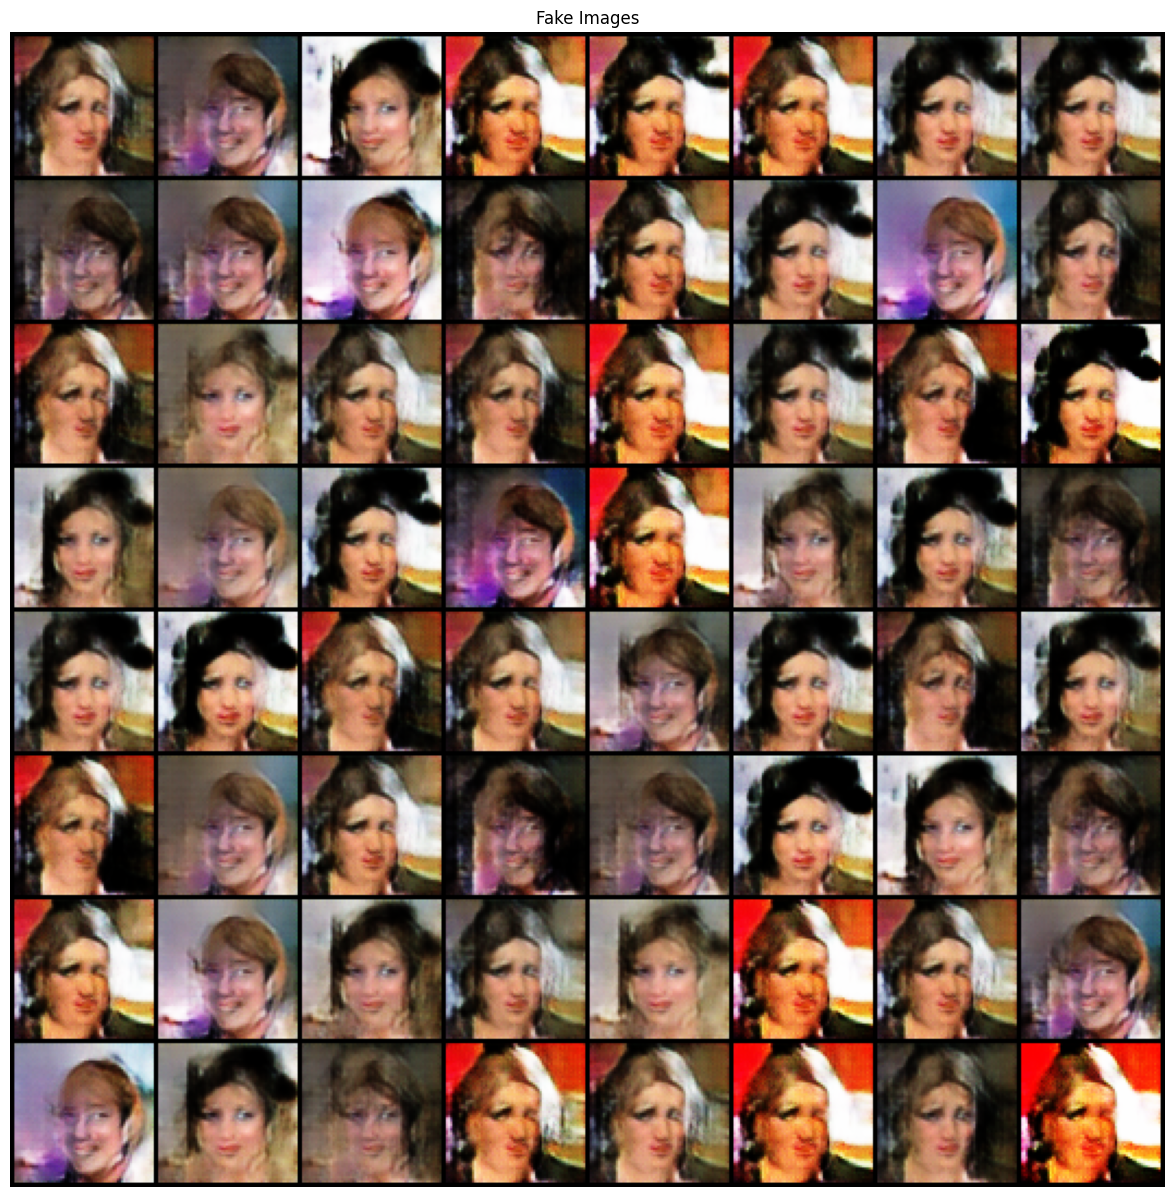

In [14]:
img_list = [] # added this cuz it was missing
noise = torch.randn(64, nz, 1, 1, device=device) # use differnet noise than during training (our fixed z)
with torch.no_grad():
    netG.eval()
    fake = netG(noise).detach().cpu()
img = vutils.make_grid(fake, padding=2, normalize=True)
img_list.append(img)
plt.figure(figsize=(15, 15))
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img.cpu(), (1, 2, 0)))
plt.savefig("fake.png")

# Pour aller plus loin...

- [Non-Saturating GAN Loss](https://danieltakeshi.github.io/2017/03/05/understanding-generative-adversarial-networks/) where the generator seeks to maximize the probability of images being real, instead of minimizing the probability of an image being fake.
- [Wasserstein Generative Adversarial Network](https://arxiv.org/abs/1701.07875) deals with gradient vanishing problems and mode collapse.